In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
def preprocess_data(csv_path):
    """
    Load CSV, remove malware rows, encode labels, split into train/val/test
    """
    df = pd.read_csv(csv_path)

    df = df.replace("benign", "normal")
    
    # Drop rows labeled as malware or defacement
    df = df[~df['type'].isin(['malware', 'defacement'])]
    
    # Ensure URL column exists
    if 'url' not in df.columns:
        raise KeyError("DataFrame must contain a 'url' column for feature extraction.")
    
    X = df[['url']].copy()
    label_mapping = {'phishing': 0, 'normal': 1}
    y = df['type'].map(label_mapping)
    
    # Train / validation / test split
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.333, random_state=42, stratify=y_temp
    )
    
    print(f"\nTrain size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")
    return X_train, y_train, X_val, y_val, X_test, y_test


In [3]:
def extract_url_features(df):
    """
    Extract URL-based features from a DataFrame containing a url column
    """
    features = pd.DataFrame()
    
    # Basic features
    features['url_length'] = df['url'].str.len()
    features['num_dots'] = df['url'].str.count(r'\.')
    features['num_hyphens'] = df['url'].str.count('-')
    features['num_underscores'] = df['url'].str.count('_')
    features['num_slashes'] = df['url'].str.count('/')
    features['num_question'] = df['url'].str.count(r'\?')
    features['num_equals'] = df['url'].str.count('=')
    features['num_at'] = df['url'].str.count('@')
    features['num_ampersand'] = df['url'].str.count('&')
    features['num_digits'] = df['url'].str.count(r'\d')
    
    # Protocol features
    features['has_https'] = df['url'].str.contains(r'https', case=False).astype(int)
    features['has_http'] = df['url'].str.contains(r'http', case=False).astype(int)
    
    # Suspicious keywords
    features['has_login'] = df['url'].str.contains(r'login', case=False).astype(int)
    features['has_verify'] = df['url'].str.contains(r'verify|confirm|account', case=False).astype(int)
    features['has_update'] = df['url'].str.contains(r'update|secure', case=False).astype(int)
    features['has_free'] = df['url'].str.contains(r'free|win|prize', case=False).astype(int)
    
    # Domain features
    features['has_ip'] = df['url'].str.contains(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}').astype(int)
    features['has_shortener'] = df['url'].str.contains(r'bit\.ly|tinyurl|goo\.gl', case=False).astype(int)
    
    return features


In [4]:
def train_random_forest(X_train, y_train):
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=10,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced',
        verbose=1
    )
    rf.fit(X_train, y_train)
    print("Training complete!")
    return rf


In [5]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Phishing', 'Normal'],
                yticklabels=['Phishing', 'Normal'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    print("\n" + "="*50)
    print("CLASSIFICATION REPORT")
    print("="*50)
    print(classification_report(y_test, y_pred, target_names=['Phishing', 'Normal']))
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nOverall Test Accuracy: {accuracy:.4f}")
    return y_pred


In [6]:
def predict_real_world_links(urls, model):
    df = pd.DataFrame({'url': urls})
    X = extract_url_features(df)
    
    predictions = model.predict(X)
    predictions_probs = model.predict_proba(X)
    
    label_map = {0: 'Phishing', 1: 'Normal'}
    
    print("\n" + "="*80)
    print("REAL-WORLD URL PREDICTIONS")
    print("="*80)
    
    for i, url in enumerate(urls):
        pred_label = label_map[predictions[i]]
        confidence = predictions_probs[i][predictions[i]] * 100
        print(f"\nURL: {url}")
        print(f"Prediction: {pred_label}")
        print(f"Confidence: {confidence:.2f}%")
        print(f"Probabilities - Phishing: {predictions_probs[i][0]:.3f}, Normal: {predictions_probs[i][1]:.3f}")
        print("-" * 80)
    
    return predictions, predictions_probs


In [7]:
def save_model(model,X_train_features):   
    filename = 'rf_model.pkl'
    with open(filename, 'wb') as file:
        pickle.dump(model, file)

    label_map = {0: 'Phishing', 1: 'Normal'}
    
    # Save as JSON
    import json
    with open("label_map.json", "w") as f:
        json.dump(label_map, f)

    feature_columns = X_train_features.columns.tolist()
    with open("feature_columns.json", "w") as f:
        json.dump(feature_columns, f)


    


Train size: 365549, Validation size: 104495, Test size: 52170


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   10.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   24.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


Training complete!


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


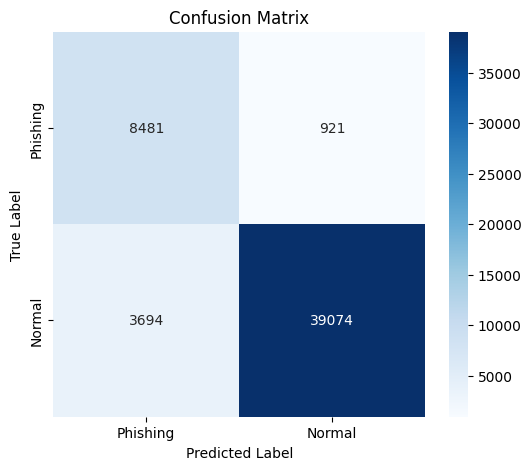


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Phishing       0.70      0.90      0.79      9402
      Normal       0.98      0.91      0.94     42768

    accuracy                           0.91     52170
   macro avg       0.84      0.91      0.87     52170
weighted avg       0.93      0.91      0.92     52170


Overall Test Accuracy: 0.9115

REAL-WORLD URL PREDICTIONS

URL: https://www.google.com
Prediction: Phishing
Confidence: 99.80%
Probabilities - Phishing: 0.998, Normal: 0.002
--------------------------------------------------------------------------------

URL: https://www.amazon.com
Prediction: Phishing
Confidence: 99.80%
Probabilities - Phishing: 0.998, Normal: 0.002
--------------------------------------------------------------------------------

URL: http://paypal-secure-login.tk/verify.php
Prediction: Phishing
Confidence: 99.20%
Probabilities - Phishing: 0.992, Normal: 0.008
---------------------------------------------------------------

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [8]:
# CSV
csv_path = "C:\\Users\\User\\Downloads\\archive\\malicious_phish.csv"

# Preprocess
X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(csv_path)

# Extract features
X_train_features = extract_url_features(X_train)
X_val_features = extract_url_features(X_val)
X_test_features = extract_url_features(X_test)

# Train model
model = train_random_forest(X_train_features, y_train)

# Evaluate
y_pred = evaluate_model(model, X_test_features, y_test)

# Real-world URL test
'''
my model predicted 2 phishing links right,and failed to predict the  2 normal links correctly,
this is expected on real world data because legit domains often look structurally similar to phishing urls,
I will add an API in the backend as a second validation layer to confirm the prediction preventing false positives on legitimate websites,
this gives room for more  robust validation'''

test_urls = [
    "https://www.google.com",
    "https://www.amazon.com",
    "http://paypal-secure-login.tk/verify.php",
    "http://accounts-google.com-signin.tk"
]
predictions, pred_probs = predict_real_world_links(test_urls, model)

saved_model=save_model(model,X_train_features)